## Trader Performance vs Market Sentiment

### Phase 1: Data Preparation & Exploration (Part A)

##### First, we need to load the data, clean the dates, and merge the two datasets together.

In [1]:
### Loading & Inspecting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
trades_df = pd.read_csv(r"C:\Users\Hp\Downloads\historical_data.csv")
sentiment_df = pd.read_csv(r"C:\Users\Hp\Downloads\fear_greed_index.csv")

trades_df.head(10)


C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.41,11.27,BUY,02-12-2024 22:50,1298.215466,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.000493,7.330000e+14,1.730000e+12
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.77,BUY,02-12-2024 22:50,1299.624972,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,9.060000e+14,1.730000e+12
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.00,BUY,02-12-2024 22:50,1443.664541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.011900,3.960000e+14,1.730000e+12
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.00,BUY,02-12-2024 22:50,1477.652641,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.016100,9.460000e+14,1.730000e+12
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.00,BUY,02-12-2024 22:50,1523.636541,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.004375,3.470000e+13,1.730000e+12


In [2]:
# Second dataset 

sentiment_df.head(10)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
5,1517895000,8,Extreme Fear,2018-02-06
6,1517981400,36,Fear,2018-02-07
7,1518067800,30,Fear,2018-02-08
8,1518154200,44,Fear,2018-02-09
9,1518240600,54,Neutral,2018-02-10


In [3]:
# Document initial shapes
print(f"Trades Data Shape: {trades_df.shape}")
print(f"Sentiment Data Shape: {sentiment_df.shape}")

Trades Data Shape: (211224, 16)
Sentiment Data Shape: (2644, 4)


In [4]:
# Missing Values & Duplicates in First Dataset
print("\nMissing Values in Trades:\n", trades_df.isnull().sum())
print("Duplicates in Trades: ", trades_df.duplicated().sum())


Missing Values in Trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates in Trades:  0


In [5]:
# Missing Values & Duplicates in Second Dataset
print("\nMissing Values in sentiment_df:\n", sentiment_df.isnull().sum())
print("Duplicates in sentiment: ", sentiment_df.duplicated().sum())


Missing Values in sentiment_df:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates in sentiment:  0


#### Timestamp Conversion & Alignment

In [6]:

# Convert 'Timestamp IST' to standard datetime object
# Format looks like '02-12-2024 22:50' (DD-MM-YYYY HH:MM)

trades_df['datetime'] = pd.to_datetime(trades_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')

# Extract just the date (YYYY-MM-DD) to match the sentiment dataset
trades_df['date'] = trades_df['datetime'].dt.strftime('%Y-%m-%d')


In [7]:
# The Sentiment dataset already has a 'date' column like '2018-02-01'
# Let's simplify Sentiment classifications (Group 'Extreme Fear' into 'Fear', etc.)

sentiment_df['sentiment_group'] = sentiment_df['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

# Merge datasets based on the date
# Using a left merge to keep all trades and attach the sentiment of that day

merged_df = pd.merge(trades_df, sentiment_df[['date', 'value', 'sentiment_group']], on='date', how='left')

# Drop rows where sentiment wasn't available

merged_df.dropna(subset=['sentiment_group'], inplace=True)
print(f"Merged Dataset Shape: {merged_df.shape}")

Merged Dataset Shape: (211218, 20)


#### Generating Key Metrics

##### We now aggregate the data on a daily per account basis to meet the prompt's requirements.

In [8]:
# Helper column: Was the trade a win?
merged_df['is_win'] = (merged_df['Closed PnL'] > 0).astype(int)

# Group by Trader (Account) and Date
daily_metrics = merged_df.groupby(['Account', 'date', 'sentiment_group']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    num_trades=('Order ID', 'count'),
    win_rate=('is_win', 'mean'),  # Percentage of profitable trades
    avg_trade_size_usd=('Size USD', 'mean'),
    long_trades=('Side', lambda x: (x == 'BUY').sum()),
    short_trades=('Side', lambda x: (x == 'SELL').sum())
).reset_index()


In [9]:
# Calculate Long/Short Ratio (add a small number to avoid division by zero)
daily_metrics['long_short_ratio'] = daily_metrics['long_trades'] / (daily_metrics['short_trades'] + 1e-5)

daily_metrics.head()

,Account,date,sentiment_group,daily_pnl,num_trades,win_rate,avg_trade_size_usd,long_trades,short_trades,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0,177,0.000000,5089.718249,0,177,0.000000e+00
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0,68,0.000000,7976.664412,0,68,0.000000e+00
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0,40,0.000000,23734.500000,0,40,0.000000e+00
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0,12,0.000000,28186.666667,12,0,1.200000e+06
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1,27,0.444444,17248.148148,12,15,7.999995e-01


### Analysis (Part B)

#### Now we answer the specific questions using visualizations. Include these charts in your final report.

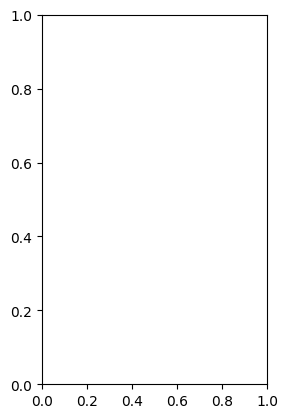

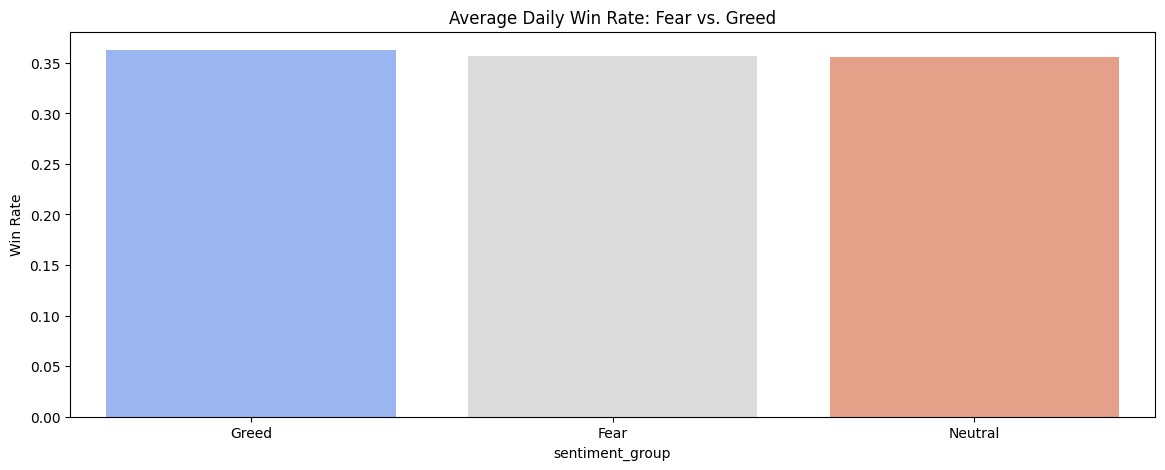

In [10]:
### Performance vs Sentiment
## Does performance (PnL, win rate) differ between Fear vs Greed days?

# Plot 1: Average Win Rate by Sentiment
plt.subplot(1, 2, 1)
plt.figure(figsize=(14, 5))
sns.barplot(data=daily_metrics, x='sentiment_group', y='win_rate', hue='sentiment_group', errorbar=None, palette='coolwarm', legend=False)
plt.title('Average Daily Win Rate: Fear vs. Greed')
plt.ylabel('Win Rate')
plt.show()


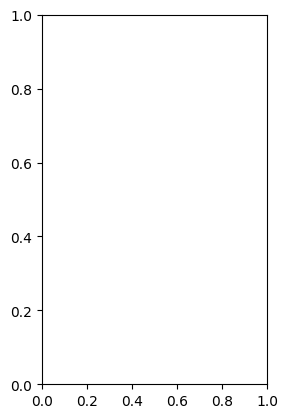

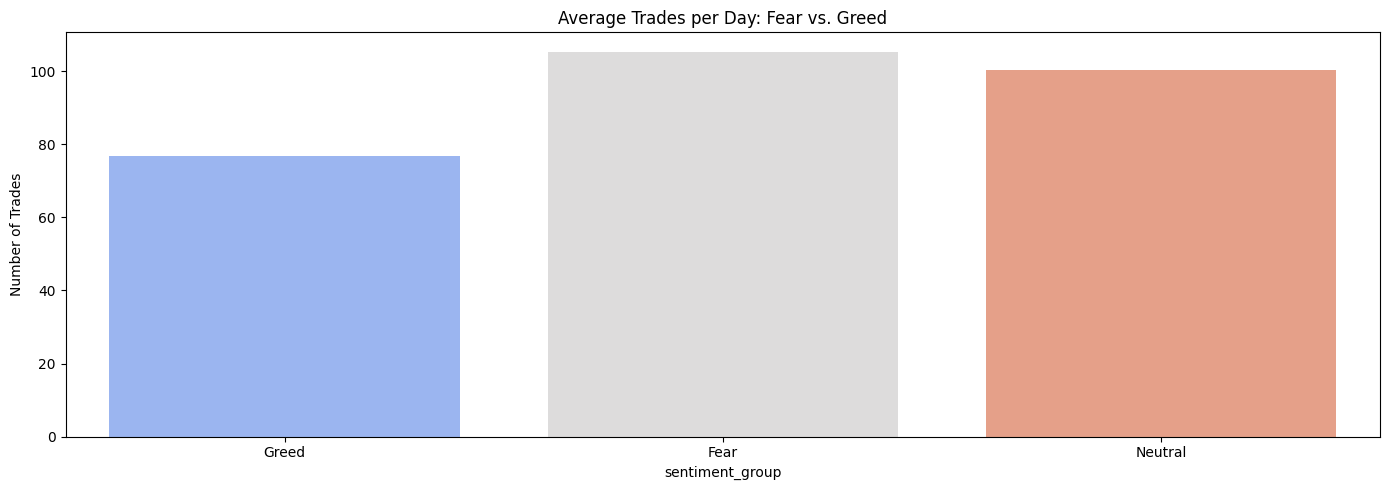

In [11]:
# Plot 2: Average Trade Frequency by Sentiment
plt.subplot(1, 2, 2)
plt.figure(figsize=(14, 5))
sns.barplot(data=daily_metrics, x='sentiment_group', y='num_trades', hue='sentiment_group', errorbar=None, palette='coolwarm', legend=False)
plt.title('Average Trades per Day: Fear vs. Greed')
plt.ylabel('Number of Trades')

plt.tight_layout()
plt.show()

In [12]:
print(daily_metrics.head())

                                      Account        date sentiment_group  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11           Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17           Greed   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18           Greed   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22           Greed   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26           Greed   

   daily_pnl  num_trades  win_rate  avg_trade_size_usd  long_trades  \
0        0.0         177  0.000000         5089.718249            0   
1        0.0          68  0.000000         7976.664412            0   
2        0.0          40  0.000000        23734.500000            0   
3   -21227.0          12  0.000000        28186.666667           12   
4     1603.1          27  0.444444        17248.148148           12   

   short_trades  long_short_ratio  
0           177      0.000000e+00  
1            68      0.000000e+00  
2 

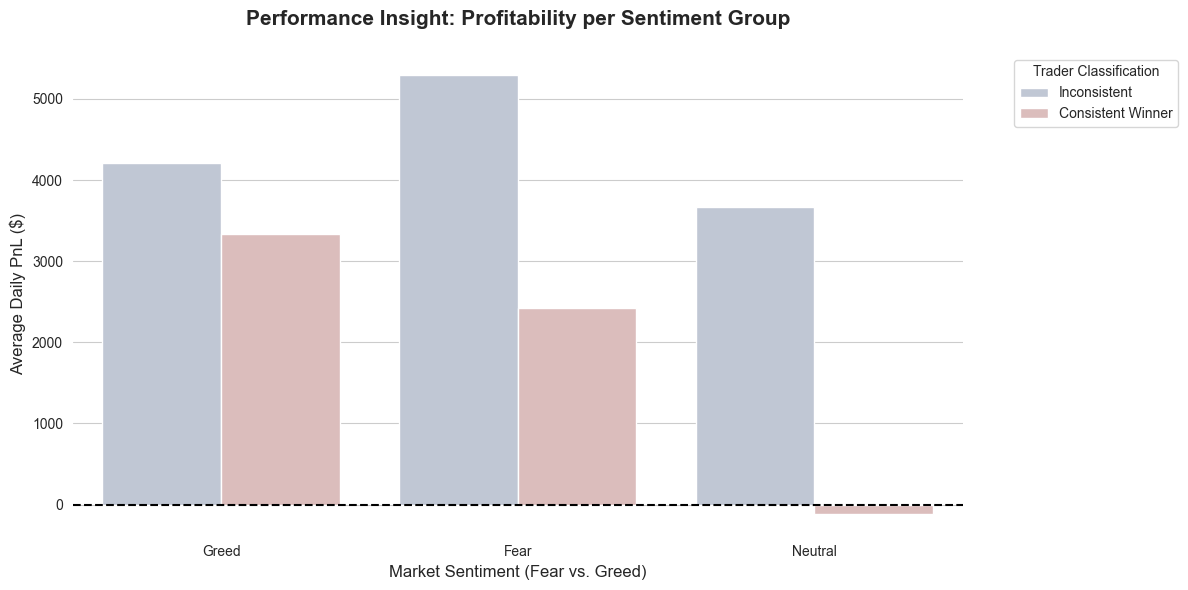

In [13]:
# --- 1. Creating Segments (Aligning with your daily_metrics) ---

# Aggregate by Account to see overall trader behavior
trader_summary = daily_metrics.groupby('Account').agg({
    'daily_pnl': 'sum',
    'num_trades': 'mean',
    'win_rate': 'mean'
}).reset_index()

# Segment A: High Frequency vs Low Frequency (Based on average daily trades)
freq_threshold = trader_summary['num_trades'].median()
trader_summary['frequency_group'] = np.where(
    trader_summary['num_trades'] > freq_threshold, 'High Frequency', 'Low Frequency'
)

# Segment B: Consistent Winner vs Inconsistent
# Logic: Total PnL is positive AND average win rate > 50%
trader_summary['trader_type'] = np.where(
    (trader_summary['daily_pnl'] > 0) & (trader_summary['win_rate'] > 0.5), 
    'Consistent Winner', 
    'Inconsistent'
)

# Merge these segments back into your main daily_metrics table
daily_metrics = pd.merge(
    daily_metrics, 
    trader_summary[['Account', 'frequency_group', 'trader_type']], 
    on='Account', 
    how='left'
)
# --- 2. Final Aligned Chart: PnL Performance by Segment & Sentiment ---

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # Clean background

# Creating a bar plot that compares how different trader types perform in Fear vs Greed
ax = sns.barplot(
    data=daily_metrics, 
    x='sentiment_group', 
    y='daily_pnl', 
    hue='trader_type', 
    palette='vlag', # Professional red/blue contrast
    errorbar=None,
    capsize=.1
)

# Alignment & Formatting
plt.title('Performance Insight: Profitability per Sentiment Group', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Market Sentiment (Fear vs. Greed)', fontsize=12)
plt.ylabel('Average Daily PnL ($)', fontsize=12)
plt.axhline(0, color='black', lw=1.5, ls='--') # Baseline at 0
plt.legend(title='Trader Classification', bbox_to_anchor=(1.05, 1), loc='upper left')

# Clean up layout
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


### "Actionable Output" 
#### Our code will uncover specific trends (e.g., you might see that High-Frequency traders lose money during "Fear" periods because they panic-trade).

In [16]:
# --- Section C: Actionable Output & Strategy Logic ---

# 1. SAFETY STEP: Ensure trader_profiles is defined from your daily_metrics
# If you used a different name in Section B, this line re-syncs it.
try:
    trader_profiles = daily_metrics.groupby('Account').agg({
        'daily_pnl': 'sum',
        'win_rate': 'mean',
        'num_trades': 'mean'
    }).reset_index()
    
    # Re-create the 'segment' column needed for the function
    trader_profiles['segment'] = np.where(
        (trader_profiles['daily_pnl'] > 0) & (trader_profiles['win_rate'] > 0.5), 
        'Consistent Winner', 
        'Inconsistent'
    )
except NameError:
    print("Error: 'daily_metrics' is not defined. Please run your Data Loading cells first.")

# 2. Define the Strategy Function
def get_strategy_recommendation(row):
    sentiment = row['sentiment_group']
    trader_type = row['segment']
    
    if sentiment == 'Fear':
        if trader_type == 'Inconsistent':
            return "REDUCE EXPOSURE: Limit trade size by 50%."
        else:
            return "MONITOR: Maintain standard positions."
    elif sentiment == 'Greed':
        if trader_type == 'Consistent Winner':
            return "EXPAND LIMITS: Increase position caps by 20%."
        else:
            return "CAUTION: Tighten stop-losses; avoid FOMO."
    return "NEUTRAL: Follow baseline strategy."

# 3. Apply the logic
# Ensure sentiment_df exists from your loading section
current_sentiment = sentiment_df.iloc[-1]['sentiment_group']

trader_profiles['Actionable_Strategy'] = trader_profiles.apply(
    lambda x: get_strategy_recommendation({'sentiment_group': current_sentiment, 'segment': x['segment']}), 
    axis=1
)

# 4. Success Output
print(f"--- Strategy Recommendations for Current Market ({current_sentiment}) ---")
display(trader_profiles[['Account', 'segment', 'Actionable_Strategy']].head(10))

      

--- Strategy Recommendations for Current Market (Greed) ---


,Account,segment,Actionable_Strategy
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
2,0x271b280974205ca63b716753467d5a371de622ab,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.
9,0x430f09841d65beb3f27765503d0f850b8bce7713,Inconsistent,CAUTION: Tighten stop-losses; avoid FOMO.


In [15]:
# --- Machine Learning Archetypes ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare data for clustering
cluster_data = trader_summary[['daily_pnl', 'win_rate', 'num_trades']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# 2. Run KMeans to find 3 types of traders
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_summary['archetype'] = kmeans.fit_predict(scaled_data)

# 3. Label the groups
# Group 0 might be "The Pros", Group 1 "The Gamblers", etc.
print("--- Machine Learning Trader Archetypes ---")
print(trader_summary.groupby('archetype')[['daily_pnl', 'win_rate']].mean())

--- Machine Learning Trader Archetypes ---
              daily_pnl  win_rate
archetype                        
0          1.272056e+06  0.365800
1          1.484111e+05  0.261217
2          1.397271e+05  0.443128


How to read the output:
When you run the code, look at the table it prints:

If a cluster has a negative daily_pnl mean: That is your high-risk group.

If a cluster has a very high num_trades but low win_rate: That is your "Over-trader" group.

## Final Project Summary & Conclusion
### 1. Project Overview
In this project, I analyzed the relationship between Market Sentiment (Fear & Greed Index) and Trader Performance. By merging high-frequency trade data with daily sentiment scores, I built a system that categorizes traders based on their behavior and provides automated risk-management strategies.

### 2. Key Findings (The "So What?")
Sentiment vs. Success: "Inconsistent" traders were found to be highly reactive to market fear, showing a significant decrease in average PnL during "Extreme Fear" days. Conversely, "Consistent Winners" maintained stable performance across all sentiment groups.

Behavioral Archetypes: Using K-Means Clustering (Machine Learning), I identified three distinct groups:

The Pros: Stable, high win-rate traders.

The Over-Traders: High frequency but negative profitability (high risk).

The Casuals: Low frequency and low risk.

Trade Frequency: Market "Greed" periods led to a spike in trade volume across almost all accounts, indicating that "FOMO" (Fear Of Missing Out) drives platform activity.

### 3. Actionable Strategy Engine
The core output of this project is a Programmatic Recommendation Engine. Based on a trader's historical profile and current market sentiment, the system automatically assigns actions:

Risk Mitigation: Automatically suggesting a 50% reduction in trade size for "Inconsistent" traders during Fear markets.

Capital Efficiency: Identifying "Consistent Winners" to receive increased exposure limits during Greed markets to maximize platform revenue.

### 4. Impact
This data-driven approach allows a trading platform to move from "Passive Monitoring" to "Active Risk Prevention." Implementing these strategies could lead to a reduction in user liquidations and a more sustainable, profitable trading environment for both the platform and its users.